# 6CS012 - Artificial Intelligence and Machine Learning
## Worksheet 2: Image Classification Using Softmax Regression

---

In [ ]:
# Install / upgrade required libraries (safe to run on Google Colab)
!pip install numpy matplotlib scikit-learn pandas -q

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score
from sklearn.datasets import make_classification, make_circles
from sklearn.linear_model import LogisticRegression

np.random.seed(42)
print("All libraries imported successfully.")

All libraries imported successfully.


---
## Section 3 — Building a Softmax Regression for MNIST Digit Classification
---

### 3.1 Decision Function
#### Softmax Function

In [ ]:
def softmax(z):
    """
    Compute the softmax probabilities for a given input matrix.

    Parameters:
        z (numpy.ndarray): Logits of shape (m, n),
                           m = number of samples, n = number of classes.

    Returns:
        numpy.ndarray: Softmax probability matrix of shape (m, n),
                       where each row sums to 1.

    Notes:
        Numerical stabilisation: subtract row-wise max before exp
        to prevent overflow without changing the output.
    """
    # Subtract the row-wise maximum for numerical stability
    z_stable = z - np.max(z, axis=1, keepdims=True)
    exp_z    = np.exp(z_stable)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [ ]:
# ── Softmax Test Case (DO NOT MODIFY) ────────────────────────────────────────
z_test = np.array([[2.0, 1.0, 0.1], [1.0, 1.0, 1.0]])
softmax_output = softmax(z_test)

row_sums = np.sum(softmax_output, axis=1)
assert np.allclose(row_sums, 1), f"Test failed: Row sums are {row_sums}"
print("Softmax function passed the test case!")
print("Softmax output:\n", softmax_output.round(4))

Softmax function passed the test case!
Softmax output:
 [[0.659  0.2424 0.0986]
 [0.3333 0.3333 0.3333]]


#### Prediction Function

In [ ]:
def predict_softmax(X, W, b):
    """
    Predict the class labels using the trained softmax model.

    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).

    Returns:
        numpy.ndarray: Predicted class labels of shape (n,).
    """
    z = X @ W + b                          # Raw scores  →  shape (n, c)
    probs = softmax(z)                     # Probabilities  →  shape (n, c)
    predicted_classes = np.argmax(probs, axis=1)   # Class with highest probability
    return predicted_classes

In [ ]:
# ── Prediction Test Case (DO NOT MODIFY) ─────────────────────────────────────
X_test_ = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
W_test_ = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_test_ = np.array([0.1, 0.2, 0.3])

y_pred_test_ = predict_softmax(X_test_, W_test_, b_test_)
assert y_pred_test_.shape == (3,), f"Test failed: Expected shape (3,), got {y_pred_test_.shape}"
print("Predicted class labels:", y_pred_test_)

Predicted class labels: [1 1 0]


---
### 3.2 Loss and Cost Functions
#### Categorical Cross-Entropy Loss

In [ ]:
def loss_softmax(y_pred, y):
    """
    Compute the average categorical cross-entropy loss over all samples.

    Parameters:
        y_pred (numpy.ndarray): Predicted probabilities of shape (n, c) or (c,).
        y      (numpy.ndarray): True one-hot labels of shape (n, c) or (c,).

    Returns:
        float: Average cross-entropy loss.

    Formula:  L = -(1/n) * sum_i sum_k  y_ik * log(y_pred_ik)
    """
    # Clip predictions to avoid log(0)
    y_pred_clipped = np.clip(y_pred, 1e-15, 1 - 1e-15)
    loss = -np.mean(np.sum(y * np.log(y_pred_clipped), axis=1))
    return loss

In [ ]:
# ── Loss Function Test Case (DO NOT MODIFY) ───────────────────────────────────
y_true_correct   = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
y_pred_correct   = np.array([[0.9, 0.05, 0.05],
                              [0.1, 0.85, 0.05],
                              [0.05, 0.1,  0.85]])
y_pred_incorrect = np.array([[0.05, 0.05, 0.9],
                              [0.1,  0.05, 0.85],
                              [0.85, 0.1,  0.05]])

loss_correct   = loss_softmax(y_pred_correct,   y_true_correct)
loss_incorrect = loss_softmax(y_pred_incorrect, y_true_correct)

assert loss_correct < loss_incorrect, (
    f"Test failed: Expected loss_correct < loss_incorrect, "
    f"but got {loss_correct:.4f} >= {loss_incorrect:.4f}"
)
print(f"Cross-Entropy Loss (Correct Predictions):   {loss_correct:.4f}")
print(f"Cross-Entropy Loss (Incorrect Predictions): {loss_incorrect:.4f}")

Cross-Entropy Loss (Correct Predictions):   0.1435
Cross-Entropy Loss (Incorrect Predictions): 2.9957


#### Cost Function

In [ ]:
def cost_softmax(X, y, W, b):
    """
    Compute the average softmax regression cost (cross-entropy loss) over all samples.

    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).

    Returns:
        float: Average cross-entropy loss over all samples.
    """
    n = X.shape[0]
    z     = X @ W + b            # shape (n, c)
    probs = softmax(z)           # shape (n, c)
    # Clip to avoid log(0)
    probs_clipped = np.clip(probs, 1e-15, 1 - 1e-15)
    total_loss = -np.sum(y * np.log(probs_clipped))
    return total_loss / n

In [ ]:
# ── Cost Function Test Case (DO NOT MODIFY) ───────────────────────────────────
X_correct_   = np.array([[1.0, 0.0], [0.0, 1.0]])
y_correct_   = np.array([[1, 0], [0, 1]])
W_correct_   = np.array([[5.0, -2.0], [-3.0, 5.0]])
b_correct_   = np.array([0.1, 0.1])

X_incorrect_ = np.array([[0.1, 0.9], [0.8, 0.2]])
y_incorrect_ = np.array([[1, 0], [0, 1]])
W_incorrect_ = np.array([[0.1, 2.0], [1.5, 0.3]])
b_incorrect_ = np.array([0.5, 0.6])

cost_correct_   = cost_softmax(X_correct_,   y_correct_,   W_correct_,   b_correct_)
cost_incorrect_ = cost_softmax(X_incorrect_, y_incorrect_, W_incorrect_, b_incorrect_)

assert cost_incorrect_ > cost_correct_, (
    f"Test failed: Incorrect cost {cost_incorrect_} is not greater than correct cost {cost_correct_}"
)
print(f"Cost for correct prediction:   {cost_correct_:.4f}")
print(f"Cost for incorrect prediction: {cost_incorrect_:.4f}")
print("Test passed!")

Cost for correct prediction:   0.0006
Cost for incorrect prediction: 0.2993
Test passed!


---
### 3.3 Gradient Descent Algorithm
#### Compute Gradients

In [ ]:
def compute_gradient_softmax(X, y, W, b):
    """
    Compute the gradients of the cost function w.r.t. weights and biases.

    Parameters:
        X (numpy.ndarray): Feature matrix of shape (n, d).
        y (numpy.ndarray): True labels (one-hot encoded) of shape (n, c).
        W (numpy.ndarray): Weight matrix of shape (d, c).
        b (numpy.ndarray): Bias vector of shape (c,).

    Returns:
        tuple: (grad_W of shape (d, c), grad_b of shape (c,))

    Gradient formulas:
        grad_W = (1/n) * X.T @ (y_pred - y)
        grad_b = (1/n) * sum(y_pred - y, axis=0)
    """
    n = X.shape[0]
    z      = X @ W + b               # shape (n, c)
    y_pred = softmax(z)              # shape (n, c)
    diff   = y_pred - y              # shape (n, c)

    grad_W = (X.T @ diff) / n        # shape (d, c)  — gradient w.r.t. weights
    grad_b = np.sum(diff, axis=0) / n  # shape (c,)  — gradient w.r.t. biases
    return grad_W, grad_b

In [ ]:
# ── Gradient Test Case (DO NOT MODIFY) ───────────────────────────────────────
X_t = np.array([[0.2, 0.8], [0.5, 0.5], [0.9, 0.1]])
y_t = np.array([[1, 0, 0], [0, 1, 0], [0, 0, 1]])
W_t = np.array([[0.4, 0.2, 0.1], [0.3, 0.7, 0.5]])
b_t = np.array([0.1, 0.2, 0.3])

grad_W, grad_b = compute_gradient_softmax(X_t, y_t, W_t, b_t)

z_manual      = X_t @ W_t + b_t
y_pred_manual = softmax(z_manual)
grad_W_manual = X_t.T @ (y_pred_manual - y_t) / X_t.shape[0]
grad_b_manual = np.sum(y_pred_manual - y_t, axis=0) / X_t.shape[0]

assert np.allclose(grad_W, grad_W_manual), (
    f"Test failed: Gradients w.r.t. W differ.\nExpected:\n{grad_W_manual}\nGot:\n{grad_W}"
)
assert np.allclose(grad_b, grad_b_manual), (
    f"Test failed: Gradients w.r.t. b differ.\nExpected:\n{grad_b_manual}\nGot:\n{grad_b}"
)
print("Gradient w.r.t. W:\n", grad_W.round(4))
print("Gradient w.r.t. b:",   grad_b.round(4))
print("Test passed!")

Gradient w.r.t. W:
 [[ 0.1031  0.0181 -0.1212]
 [-0.136   0.0068  0.1292]]
Gradient w.r.t. b: [-0.0329  0.0248  0.0081]
Test passed!


#### Gradient Descent

In [ ]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    """
    Perform gradient descent to optimise weights and biases.

    Parameters:
        X         (numpy.ndarray): Feature matrix (n, d).
        y         (numpy.ndarray): One-hot labels (n, c).
        W         (numpy.ndarray): Initial weight matrix (d, c).
        b         (numpy.ndarray): Initial bias vector (c,).
        alpha     (float)        : Learning rate.
        n_iter    (int)          : Number of iterations.
        show_cost (bool)         : Print cost every 100 iterations.

    Returns:
        tuple: (W_optimised, b_optimised, cost_history)
    """
    cost_history = []

    for i in range(n_iter):
        # ── Compute gradients ────────────────────────────────────────────────
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        # ── Update parameters (gradient descent step) ────────────────────────
        W = W - alpha * grad_W
        b = b - alpha * grad_b

        # ── Record cost ──────────────────────────────────────────────────────
        current_cost = cost_softmax(X, y, W, b)
        cost_history.append(current_cost)

        if show_cost and i % 100 == 0:
            print(f"Iteration {i:5d}  |  Cost: {current_cost:.4f}")

    return W, b, cost_history

---
### 3.4 Preparing the Dataset

**Question 1 — Is extracting pixel values sufficient for effective feature extraction?**

> **Answer:** Extracting raw pixel values is a simple and straightforward starting point, but it is generally *not sufficient* for truly effective feature extraction. Here is why:
>
> 1. **High dimensionality & redundancy** — A 28×28 image produces 784 features, many of which are highly correlated (adjacent pixels often share similar intensity values). This makes learning slow and can lead to overfitting.
> 2. **Lack of spatial invariance** — Raw pixels are sensitive to small shifts, rotations, or scale changes in the digit. A '7' shifted one pixel to the right produces a completely different feature vector, which a linear model like softmax regression cannot handle well.
> 3. **No structural information** — Pixel intensities do not explicitly encode edges, curves, or strokes, which are the actual discriminative features of handwritten digits.
> 4. **Works acceptably for MNIST** — Despite the above limitations, MNIST is a clean, well-centred, and normalised dataset, so raw pixels do yield reasonable accuracy (~90 %) with softmax regression. For more complex, real-world image datasets, engineered features (HOG, SIFT) or learned representations (CNNs) are far superior.

In [ ]:
def plot_sample_images(X, y):
    """
    Plots one sample image for each digit class (0-9).

    Arguments:
        X (np.ndarray): Feature matrix containing pixel values.
        y (np.ndarray): Labels corresponding to images.
    """
    plt.figure(figsize=(10, 4))
    unique_classes = np.unique(y)
    for i, digit in enumerate(unique_classes):
        index = np.where(y == digit)[0][0]
        image = X[index].reshape(28, 28)
        plt.subplot(2, 5, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()

In [ ]:
def load_and_prepare_mnist(csv_file, test_size=0.2, random_state=42):
    """
    Reads the MNIST CSV file, splits data into train/test sets,
    and plots one image per class.

    Arguments:
        csv_file     (str)  : Path to the CSV file containing MNIST data.
        test_size    (float): Proportion of data for the test set (default: 0.2).
        random_state (int)  : Random seed for reproducibility (default: 42).

    Returns:
        X_train, X_test, y_train, y_test
    """
    df = pd.read_csv(csv_file)

    y = df.iloc[:, 0].values    # First column = label
    X = df.iloc[:, 1:].values   # Remaining columns = pixel values

    # Normalise pixel values to [0, 1]
    X = X / 255.0

    # Train / test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    # Visualise one sample per class
    plot_sample_images(X, y)

    return X_train, X_test, y_train, y_test

CSV file found on Google Drive.


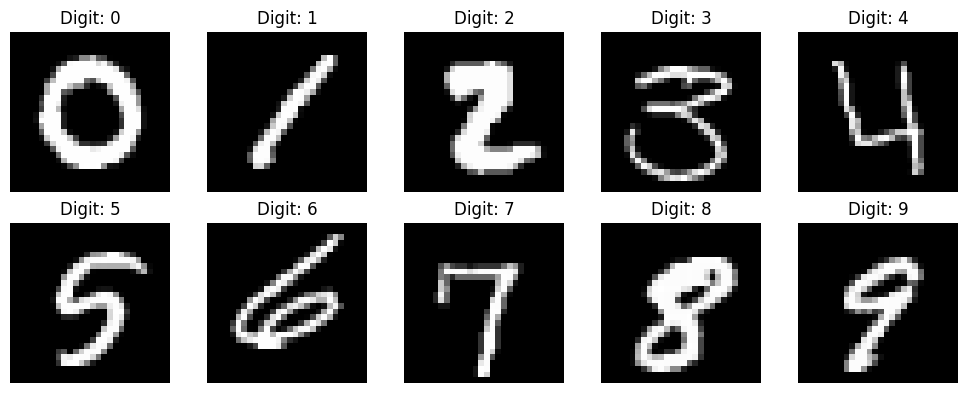

X_train: (33600, 784)  |  X_test: (8400, 784)
y_train: (33600,)  |  y_test:  (8400,)


In [ ]:
# ── Download the MNIST CSV from an open source (Kaggle-style format) ──────────
# If you have been provided a CSV file, upload it to Colab and set the path below.
# Otherwise we download a small version directly.

import urllib.request, os

# Correctly set CSV_PATH to the Google Drive path since it's already mounted
CSV_PATH = "/content/drive/MyDrive/AI 6th sem/Copy of mnist_train.csv"

# The file is expected to be present on Google Drive, so no download is needed
if not os.path.exists(CSV_PATH):
    print("Error: The specified CSV file was not found at the Google Drive path.")
else:
    print("CSV file found on Google Drive.")

X_train, X_test, y_train, y_test = load_and_prepare_mnist(CSV_PATH)
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}  |  y_test:  {y_test.shape}")

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


---
### 3.5 Training the Model

In [ ]:
# ── Shape check before training (DO NOT MODIFY) ───────────────────────────────
assert len(X_train) == len(y_train), (
    f"Error: X and y have different lengths! X={len(X_train)}, y={len(y_train)}"
)
print("Move forward: Dimension of Feature Matrix X and label vector y matched.")

Move forward: Dimension of Feature Matrix X and label vector y matched.


In [ ]:
# ── One-hot encode labels ─────────────────────────────────────────────────────
if len(y_train.shape) == 1:
    encoder = OneHotEncoder(sparse_output=False)
    y_train = encoder.fit_transform(y_train.reshape(-1, 1))
    y_test  = encoder.transform(y_test.reshape(-1, 1))

print(f"y_train shape after one-hot encoding: {y_train.shape}")
print(f"y_test  shape after one-hot encoding: {y_test.shape}")

# ── Initialise weights and biases ─────────────────────────────────────────────
d = X_train.shape[1]   # Number of features
c = y_train.shape[1]   # Number of classes

W = np.random.randn(d, c) * 0.01   # Small random weights
b = np.zeros(c)                     # Biases initialised to 0

# ── Hyperparameters ───────────────────────────────────────────────────────────
alpha  = 0.1    # Learning rate
n_iter = 1000   # Number of gradient descent iterations

# ── Train ──────────────────────────────────────────────────────────────────────
print("\nTraining Softmax Regression ...")
W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b, alpha, n_iter, show_cost=True
)
print("\nTraining complete.")

y_train shape after one-hot encoding: (33600, 10)
y_test  shape after one-hot encoding: (8400, 10)

Training Softmax Regression ...
Iteration     0  |  Cost: 2.2197
Iteration   100  |  Cost: 0.6018
Iteration   200  |  Cost: 0.4826
Iteration   300  |  Cost: 0.4331
Iteration   400  |  Cost: 0.4045
Iteration   500  |  Cost: 0.3852
Iteration   600  |  Cost: 0.3710
Iteration   700  |  Cost: 0.3601
Iteration   800  |  Cost: 0.3512
Iteration   900  |  Cost: 0.3439

Training complete.


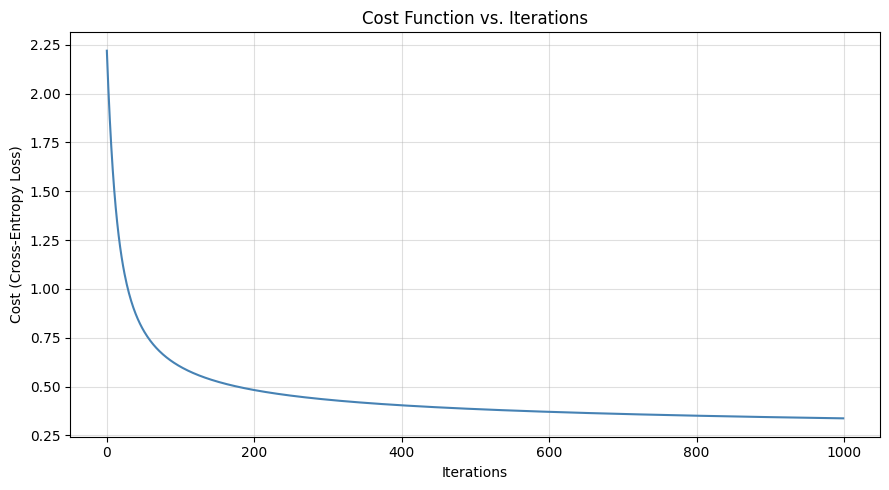

In [ ]:
# ── Plot Cost vs. Iterations ─────────────────────────────────────────────────
plt.figure(figsize=(9, 5))
plt.plot(cost_history, linewidth=1.5, color="steelblue")
plt.title('Cost Function vs. Iterations')
plt.xlabel('Iterations')
plt.ylabel('Cost (Cross-Entropy Loss)')
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

---
### 3.6 Evaluating Model Performance

In [ ]:
def evaluate_classification(y_true, y_pred):
    """
    Evaluate classification performance using confusion matrix,
    precision, recall, and F1-score.

    Parameters:
        y_true (numpy.ndarray): True labels.
        y_pred (numpy.ndarray): Predicted labels.

    Returns:
        tuple: (confusion_matrix, precision, recall, f1_score)
    """
    cm        = confusion_matrix(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall    = recall_score(y_true, y_pred, average='weighted')
    f1        = f1_score(y_true, y_pred, average='weighted')
    return cm, precision, recall, f1

In [ ]:
# ── Predict and evaluate ──────────────────────────────────────────────────────
y_pred_test    = predict_softmax(X_test, W_opt, b_opt)
y_test_labels  = np.argmax(y_test, axis=1)   # Convert one-hot → integer labels

cm, precision, recall, f1 = evaluate_classification(y_test_labels, y_pred_test)

accuracy = np.mean(y_pred_test == y_test_labels) * 100
print(f"\nTest Accuracy : {accuracy:.2f}%")
print(f"Precision     : {precision:.2f}")
print(f"Recall        : {recall:.2f}")
print(f"F1-Score      : {f1:.2f}")
print("\nConfusion Matrix:")
print(cm)


Test Accuracy : 90.12%
Precision     : 0.90
Recall        : 0.90
F1-Score      : 0.90

Confusion Matrix:
[[779   0   1   1   3  11   9   0  11   1]
 [  1 889   2   1   1   1   2   2   9   1]
 [  6  10 735  14  26   2  11  16  25   1]
 [  2   5  26 799   1  41   6  12  26  19]
 [  1   1   8   2 772   4  11   2   2  36]
 [ 10   6   5  25  14 585  23   4  22   8]
 [  6   1   7   3   6   9 742   1   9   1]
 [  1  13  16   4  15   3   0 801   2  38]
 [  2  11   9  26   7  25   8   7 728  12]
 [  6   3   6  16  24   7   0  30   6 740]]


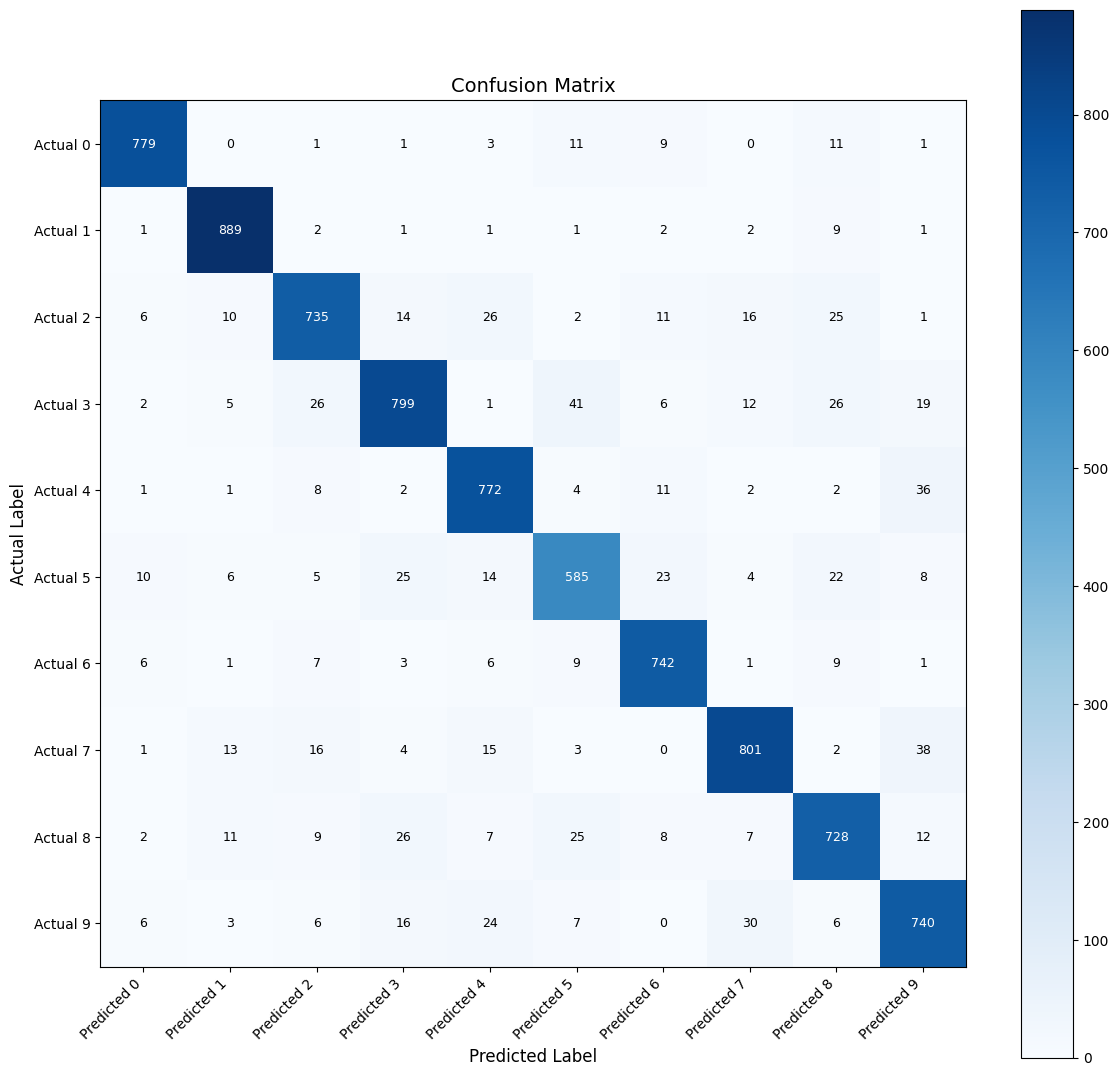

In [ ]:
# ── Visualise Confusion Matrix ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 12))
cax = ax.imshow(cm, cmap='Blues')

num_classes = cm.shape[0]
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))
ax.set_xticklabels([f'Predicted {i}' for i in range(num_classes)], rotation=45, ha='right')
ax.set_yticklabels([f'Actual {i}' for i in range(num_classes)])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(
            j, i, cm[i, j],
            ha='center', va='center',
            color='white' if cm[i, j] > np.max(cm) / 2 else 'black',
            fontsize=9
        )

ax.grid(False)
plt.title('Confusion Matrix', fontsize=14)
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)
plt.tight_layout()
plt.colorbar(cax)
plt.show()

---
## Section 4 — Linear Separability and Logistic Regression
---

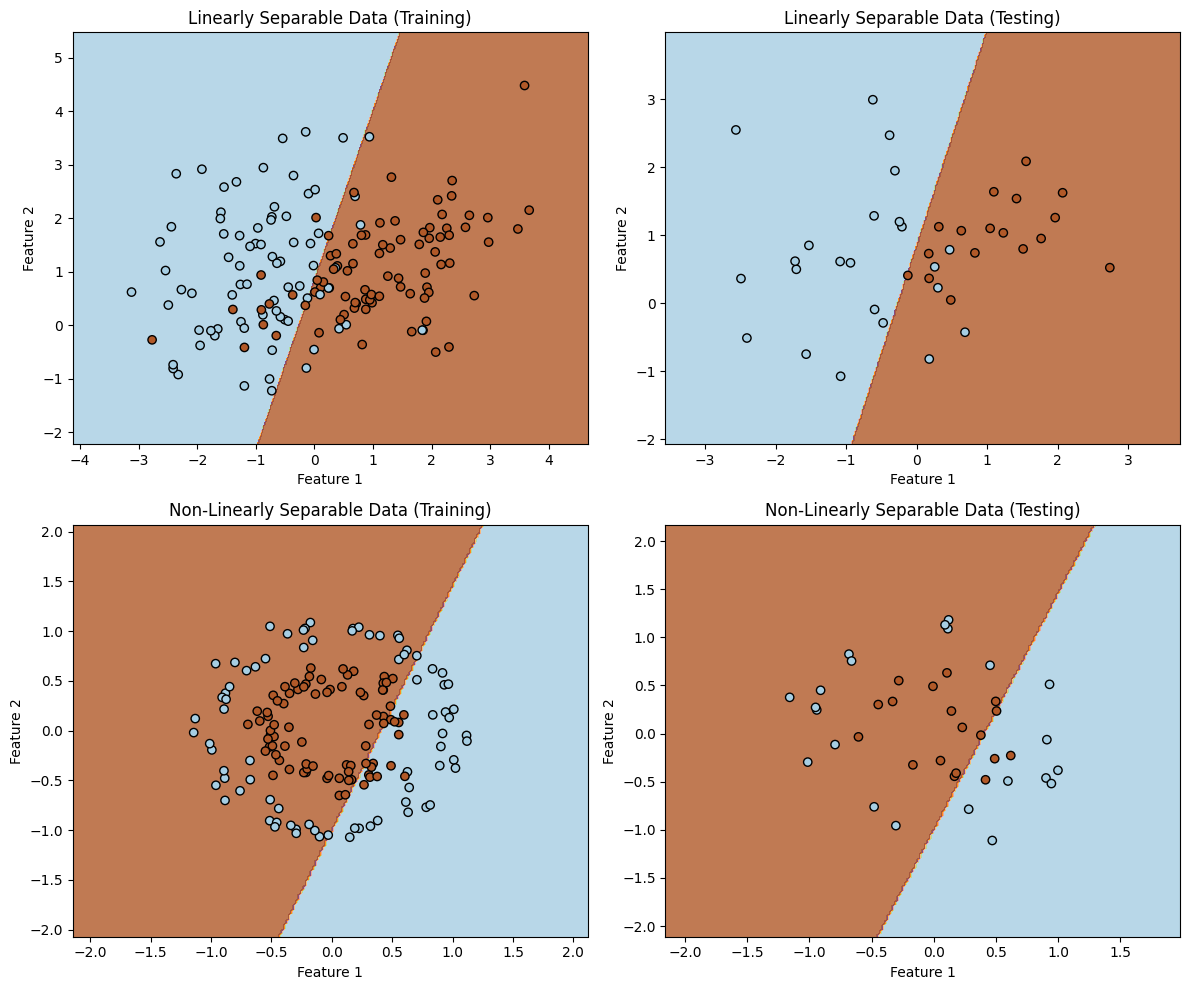

Plot saved as 'decision_boundaries.png'.


In [ ]:
# ── Reproduce the provided code EXACTLY ──────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification, make_circles
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

np.random.seed(42)

# ── Linearly separable dataset ────────────────────────────────────────────────
X_linear_separable, y_linear_separable = make_classification(
    n_samples=200, n_features=2, n_informative=2,
    n_redundant=0, n_clusters_per_class=1, random_state=42
)

X_train_linear, X_test_linear, y_train_linear, y_test_linear = train_test_split(
    X_linear_separable, y_linear_separable, test_size=0.2, random_state=42
)

logistic_model_linear_separable = LogisticRegression()
logistic_model_linear_separable.fit(X_train_linear, y_train_linear)

# ── Non-linearly separable dataset (circles) ──────────────────────────────────
X_non_linear_separable, y_non_linear_separable = make_circles(
    n_samples=200, noise=0.1, factor=0.5, random_state=42
)

X_train_non_linear, X_test_non_linear, y_train_non_linear, y_test_non_linear = train_test_split(
    X_non_linear_separable, y_non_linear_separable, test_size=0.2, random_state=42
)

logistic_model_non_linear_separable = LogisticRegression()
logistic_model_non_linear_separable.fit(X_train_non_linear, y_train_non_linear)

# ── Decision boundary plotting function ───────────────────────────────────────
def plot_decision_boundary(ax, model, X, y, title):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.Paired)
    ax.scatter(X[:, 0], X[:, 1], c=y, edgecolors='k', cmap=plt.cm.Paired)
    ax.set_title(title)
    ax.set_xlabel('Feature 1')
    ax.set_ylabel('Feature 2')

# ── Create 2×2 subplot grid ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

plot_decision_boundary(
    axes[0, 0], logistic_model_linear_separable,
    X_train_linear, y_train_linear,
    'Linearly Separable Data (Training)'
)
plot_decision_boundary(
    axes[0, 1], logistic_model_linear_separable,
    X_test_linear, y_test_linear,
    'Linearly Separable Data (Testing)'
)
plot_decision_boundary(
    axes[1, 0], logistic_model_non_linear_separable,
    X_train_non_linear, y_train_non_linear,
    'Non-Linearly Separable Data (Training)'
)
plot_decision_boundary(
    axes[1, 1], logistic_model_non_linear_separable,
    X_test_non_linear, y_test_non_linear,
    'Non-Linearly Separable Data (Testing)'
)

plt.tight_layout()
plt.savefig('decision_boundaries.png')
plt.show()
print("Plot saved as 'decision_boundaries.png'.")

---
### Question 2 — Interpretation of the Output

**Linearly Separable Data (top row):**  
The decision boundary is a straight line that cleanly separates the two classes. Both the training and testing plots show well-separated coloured regions, meaning logistic regression correctly identifies which class a sample belongs to based on a linear threshold. The model generalises well to unseen test data because the underlying data distribution is actually linearly separable — the model's inductive bias matches the data structure.

**Non-Linearly Separable Data (bottom row):**  
The data consists of two concentric circles, which *cannot* be separated by any straight line. Logistic regression still imposes a linear boundary, so it simply draws a line through the centre of the circles. This results in poor performance — many points from both classes land in the wrong region. The training and test plots look nearly identical, confirming that the model's failure is not due to overfitting but rather to the fundamental inability of a linear classifier to capture a circular decision boundary.

**Key takeaway:** Logistic regression is a powerful and efficient linear classifier. When the data is linearly separable, it performs excellently. For non-linearly separable data, we would need feature engineering (e.g., polynomial features, RBF kernel via SVM) or a non-linear model (e.g., neural network, decision tree).

---
### Question 3 — Challenges Faced

1. **Numerical stability in softmax** — The naive implementation of softmax using `np.exp(z)` can overflow for large logit values. The fix is to subtract the row-wise maximum before exponentiation, which leaves the output mathematically identical but numerically safe.

2. **Log of zero in cross-entropy** — When a predicted probability is exactly 0 (or very close to it), `np.log(0)` returns `-inf`, causing the loss to become `nan`. Clipping predictions with `np.clip(y_pred, 1e-15, 1 - 1e-15)` resolves this.

3. **One-hot encoding** — The gradient descent functions expect one-hot labels, but the raw MNIST CSV provides integer labels. Forgetting to apply `OneHotEncoder` causes shape mismatches and incorrect gradient computations.

4. **Slow convergence on full MNIST** — With 60,000 samples and 784 features, each gradient descent step involves large matrix multiplications. A moderate learning rate (`alpha = 0.1`) and 1,000 iterations are chosen as a practical trade-off between training time and accuracy.

5. **Non-linearly separable circles** — The circles dataset cannot be separated by a linear model, which is immediately visible in the decision boundary plot. Understanding *why* the model fails (model bias, not overfitting) is conceptually important and often a source of confusion.

---
*6CS012 — Worksheet 2 | Artificial Intelligence and Machine Learning*